In [ ]:
!pip install -q kaggle


import json
import os

kaggle_api = {
    "username": "khtttcf",
    "key": "a87cf0d78a82e9a95910d3adb081a16f"
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_api, f)

!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d landlord/handwriting-recognition


!mkdir -p handwriting_dataset
!unzip -q handwriting-recognition.zip -d handwriting_dataset


!ls handwriting_dataset


Dataset URL: https://www.kaggle.com/datasets/landlord/handwriting-recognition
License(s): CC0-1.0
 99% 1.25G/1.26G [00:12<00:00, 83.5MB/s]
100% 1.26G/1.26G [00:12<00:00, 107MB/s] 
test_v2   validation_v2		    written_name_train_v2.csv
train_v2  written_name_test_v2.csv  written_name_validation_v2.csv


In [ ]:
import os
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
class HandwritingDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(root_dir)))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.imgs[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.as_tensor(img, dtype=torch.float32).permute(2,0,1)/255.0


        boxes = torch.tensor([[0,0,img.shape[2],img.shape[1]]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)


In [ ]:
dataset = HandwritingDataset('handwriting_dataset')
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [ ]:

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)


num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 118MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
import os
import torch
from torch.utils.data import Dataset
import cv2

class HandwritingDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms
        self.imgs = []
        valid_exts = [".png", ".jpg", ".jpeg", ".bmp"]
        for root, _, files in os.walk(root_dir):
            for f in files:
                if os.path.splitext(f)[1].lower() in valid_exts:
                    self.imgs.append(os.path.join(root, f))
        if len(self.imgs) == 0:
            raise ValueError(f"No images found in {root_dir}")

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Failed to read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = torch.as_tensor(img, dtype=torch.float32).permute(2,0,1)/255.0

        boxes = torch.tensor([[0, 0, img.shape[2], img.shape[1]]], dtype=torch.float32)
        labels = torch.tensor([1], dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        if self.transforms:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)


In [ ]:
dataset = HandwritingDataset('handwriting_dataset')
data_loader = torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))


In [ ]:


device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)


In [ ]:
from torch.utils.data import random_split, Subset
from tqdm import tqdm
import random
import torch

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

subset_size = min(200, len(dataset))
subset_indices = random.sample(range(len(dataset)), subset_size)
dataset_subset = Subset(dataset, subset_indices)

val_ratio = 0.2
val_size = int(val_ratio * subset_size)
train_size = subset_size - val_size
train_dataset, val_dataset = random_split(dataset_subset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

num_epochs = 5
patience = 3
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        train_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    train_loss /= len(train_loader)

    # Validation: compute loss + accuracy
    model.train()  # compute loss in train mode with no_grad
    val_loss = 0.0
    correct = 0
    total_gt = 0
    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
            if len(images) == 0 or len(targets) == 0:
                continue
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # validation loss
            outputs = model(images, targets)
            if isinstance(outputs, dict):
                losses = sum(loss for loss in outputs.values())
                val_loss += losses.item()

            # accuracy using predictions
            model.eval()  # switch to eval mode for predictions
            pred_outputs = model(images)  # no targets
            for i, out in enumerate(pred_outputs):
                gt_boxes = targets[i]["boxes"].cpu().numpy()
                pred_boxes = out["boxes"].cpu().numpy()
                total_gt += len(gt_boxes)
                for gt in gt_boxes:
                    if len(pred_boxes) == 0:
                        continue
                    ious = [compute_iou(gt, pb) for pb in pred_boxes]
                    if max(ious) >= 0.5:
                        correct += 1
            model.train()  # switch back to train mode for next batch

    val_loss /= len(val_loader) if len(val_loader) > 0 else 1
    accuracy = 100 * correct / total_gt if total_gt > 0 else 0

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  Val Acc: {accuracy:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        print(f"No improvement for {counter} epochs")
        if counter >= patience:
            print("Early stopping triggered")
            break


Epoch 1 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.42it/s]


Epoch [1/5]  Train Loss: 0.0170  Val Loss: 0.0129  Val Acc: 100.00%


Epoch 2 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.38it/s]


Epoch [2/5]  Train Loss: 0.0161  Val Loss: 0.0127  Val Acc: 100.00%


Epoch 3 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.23it/s]


Epoch [3/5]  Train Loss: 0.0167  Val Loss: 0.0184  Val Acc: 100.00%
No improvement for 1 epochs


Epoch 4 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.49it/s]


Epoch [4/5]  Train Loss: 0.0183  Val Loss: 0.0162  Val Acc: 100.00%
No improvement for 2 epochs


Epoch 5 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.45it/s]

Epoch [5/5]  Train Loss: 0.0156  Val Loss: 0.0140  Val Acc: 100.00%
No improvement for 3 epochs
Early stopping triggered


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

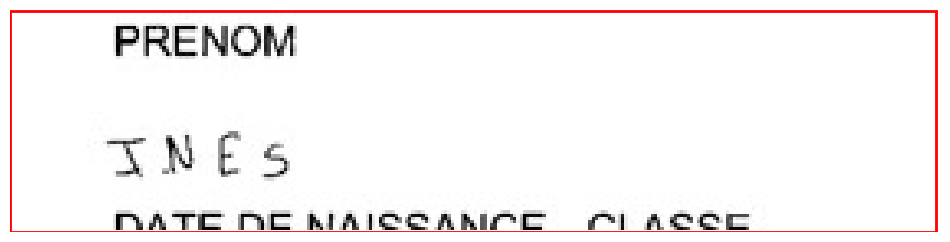

In [ ]:
import matplotlib.pyplot as plt

img, _ = dataset[0]
img = img.to(device)
with torch.no_grad():
    pred = model([img])[0]

img_np = img.permute(1,2,0).cpu().numpy()
height, width, _ = img_np.shape

plt.figure(figsize=(12, 12))
plt.imshow(img_np)

# Draw predicted boxes
for box in pred['boxes'].cpu().numpy():
    x1, y1, x2, y2 = box
    plt.gca().add_patch(plt.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        fill=False, edgecolor='red', linewidth=2
    ))

plt.xlim(0, width)
plt.ylim(height, 0)  # invert y-axis to match image coordinates
plt.axis('off')
plt.show()


In [ ]:
total_correct = 0
total_gt = 0
with torch.no_grad():
    for images, targets in val_loader:
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        preds = model(images)
        for i, pred in enumerate(preds):
            gt_boxes = targets[i]['boxes'].cpu().numpy()
            pred_boxes = pred['boxes'].cpu().numpy()
            total_gt += len(gt_boxes)
            for gt in gt_boxes:
                if len(pred_boxes) == 0:
                    continue
                ious = [compute_iou(gt, pb) for pb in pred_boxes]
                if max(ious) >= 0.5:
                    total_correct += 1
accuracy = 100 * total_correct / total_gt
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Accuracy: 100.00%


In [ ]:
import torch
from tqdm import tqdm

def evaluate_model(model, data_loader, device):
    model.eval()
    total_correct = 0
    total_gt = 0
    total_loss = 0.0
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluating"):
            images = list(img.to(device) for img in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Compute loss (in train mode)
            model.train()
            outputs = model(images, targets)
            if isinstance(outputs, dict):
                total_loss += sum(loss for loss in outputs.values()).item()
            model.eval()

            # Compute accuracy
            preds = model(images)
            for i, pred in enumerate(preds):
                gt_boxes = targets[i]["boxes"].cpu().numpy()
                pred_boxes = pred["boxes"].cpu().numpy()
                total_gt += len(gt_boxes)
                for gt in gt_boxes:
                    if len(pred_boxes) == 0:
                        continue
                    ious = [compute_iou(gt, pb) for pb in pred_boxes]
                    if max(ious) >= 0.5:
                        total_correct += 1

    avg_loss = total_loss / len(data_loader) if len(data_loader) > 0 else 0
    accuracy = 100 * total_correct / total_gt if total_gt > 0 else 0
    return avg_loss, accuracy


In [ ]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # training loop (same as before) ...
    train_losses.append(train_loss)
    val_losses.append(val_loss)


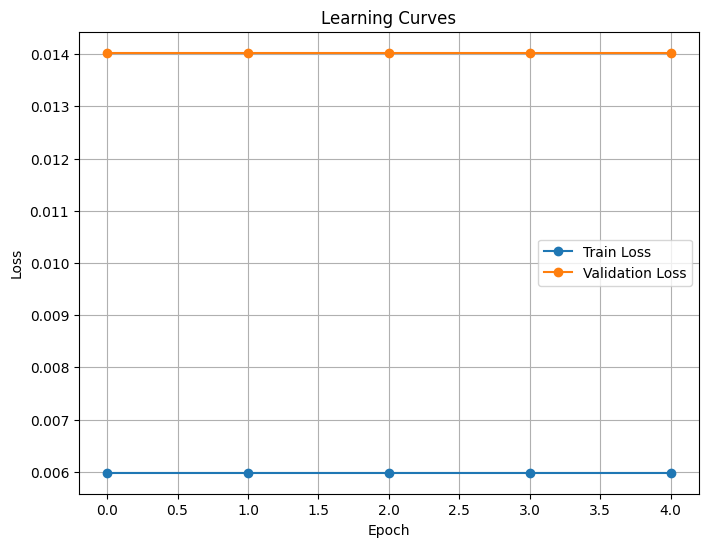

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()


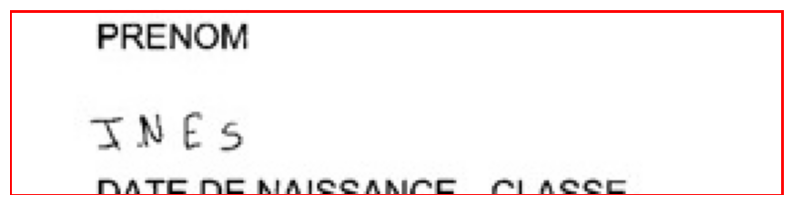

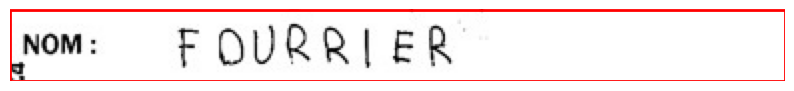

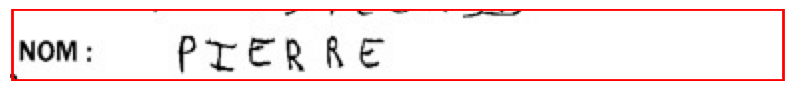

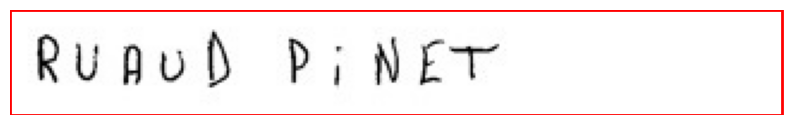

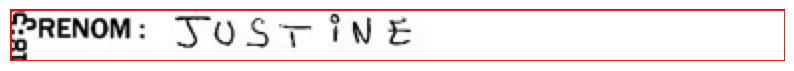

In [ ]:
import matplotlib.pyplot as plt

def demo_predictions(model, dataset, device, num_images=5):
    model.eval()
    for idx in range(num_images):
        img, _ = dataset[idx]
        img = img.to(device)
        with torch.no_grad():
            pred = model([img])[0]

        # Move to CPU for plotting
        img_np = img.permute(1,2,0).cpu().numpy()

        # Normalize if needed (in case image is [0,1] or [0,255])
        if img_np.max() > 1.0:
            img_np = img_np / 255.0

        height, width, _ = img_np.shape

        plt.figure(figsize=(10,10))
        plt.imshow(img_np)

        for box in pred['boxes'].cpu().numpy():
            x1, y1, x2, y2 = box
            plt.gca().add_patch(plt.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                fill=False, edgecolor='red', linewidth=2
            ))

        plt.xlim(0, width)
        plt.ylim(height, 0)
        plt.axis('off')
        plt.show()

# Make sure matplotlib inline mode is enabled in Colab
%matplotlib inline

# Run the demo
demo_predictions(model, dataset, device, num_images=5)


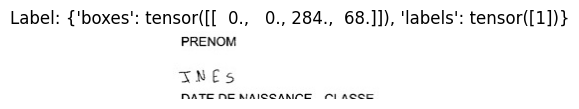

In [ ]:
import matplotlib.pyplot as plt

def show_images(dataset, num_images=10):
    plt.figure(figsize=(15, 5))

    for i in range(num_images):
        img, label = dataset[i]
        img_np = img.permute(1,2,0).cpu().numpy()
        if img_np.shape[2] == 1:  # grayscale
            img_np = img_np.squeeze(2)
        if img_np.max() > 1.0:
            img_np = img_np / 255.0

        plt.subplot(2, 5, i+1)
        plt.imshow(img_np, cmap='gray')
        plt.axis('off')
        plt.title(f"Label: {label}")

    plt.tight_layout()
    plt.show()

# Display 10 images
show_images(dataset, num_images=1)


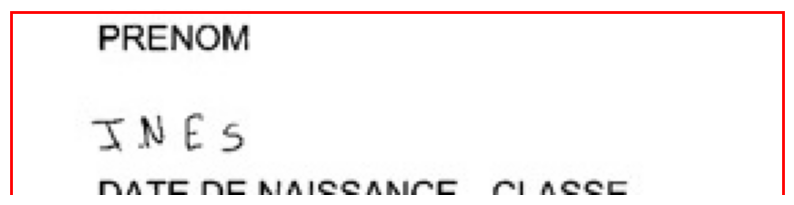

In [ ]:
import matplotlib.pyplot as plt
import torch

# Take the first image
img, _ = dataset[0]
img = img.to(device)

model.eval()
with torch.no_grad():
    pred = model([img])[0]  # detection model output

# Plot image
img_np = img.permute(1,2,0).cpu().numpy()
if img_np.max() > 1.0:
    img_np = img_np / 255.0

plt.figure(figsize=(10,10))
plt.imshow(img_np)

# Draw predicted boxes
for box in pred['boxes'].cpu().numpy():
    x1, y1, x2, y2 = box
    plt.gca().add_patch(plt.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        fill=False, edgecolor='red', linewidth=2
    ))

plt.axis('off')
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 31.3 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

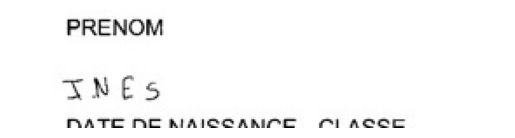

Detected text: PRENOM, Confidence: 1.00
Detected text: E 5, Confidence: 0.83
Detected text: IATTC, Confidence: 0.09
Detected text: Tn, Confidence: 0.63


In [ ]:
!pip install easyocr
import easyocr
import matplotlib.pyplot as plt

# Initialize reader
reader = easyocr.Reader(['en'])  # 'en' for English

# Take first image from dataset
img, _ = dataset[0]

# Convert PyTorch tensor to numpy image
img_np = img.permute(1,2,0).cpu().numpy()
if img_np.max() > 1.0:
    img_np = img_np / 255.0

# easyOCR expects grayscale or RGB
if img_np.shape[2] == 1:
    img_np = img_np.squeeze(2)

# Display the image
plt.imshow(img_np, cmap='gray')
plt.axis('off')
plt.show()

# Predict text
results = reader.readtext((img_np * 255).astype('uint8'))
for (bbox, text, prob) in results:
    print(f"Detected text: {text}, Confidence: {prob:.2f}")


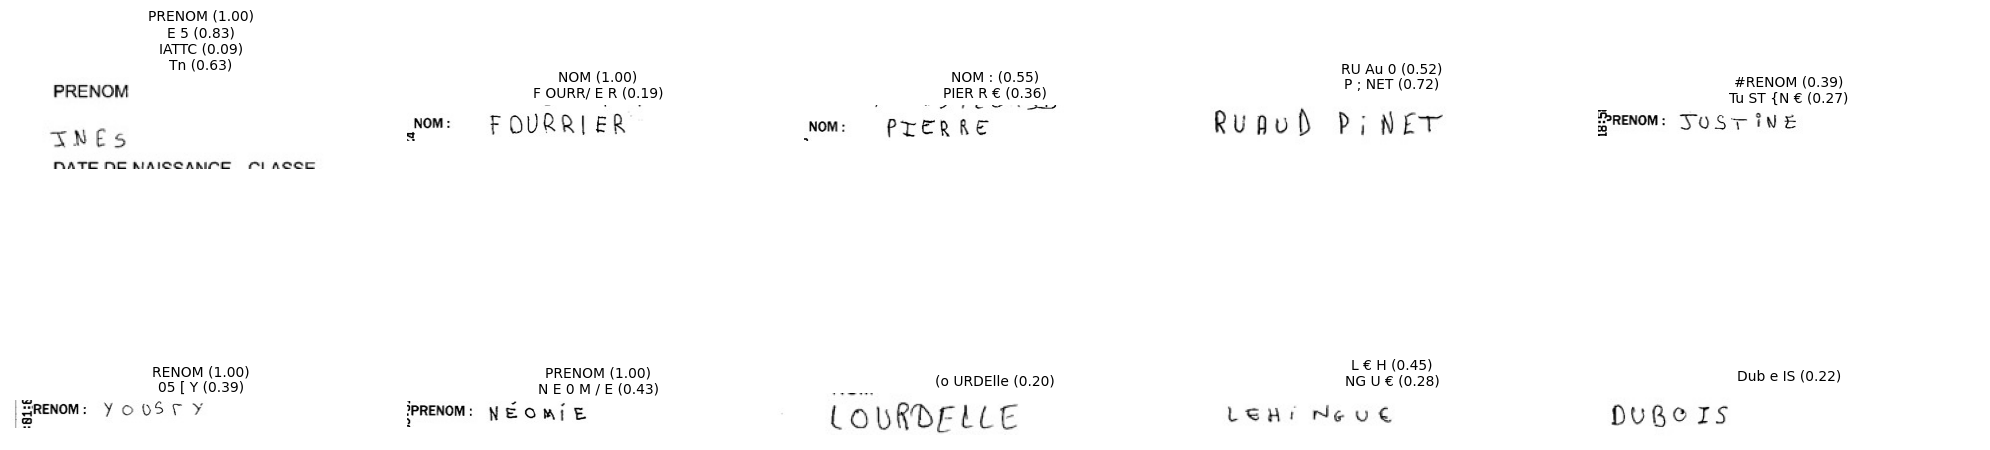

In [ ]:
!pip install easyocr
import easyocr
import matplotlib.pyplot as plt

# Initialize OCR reader
reader = easyocr.Reader(['en'])  # English

def show_predictions(dataset, num_images=10):
    plt.figure(figsize=(20, 8))

    for i in range(num_images):
        img, _ = dataset[i]

        # Convert tensor to numpy
        img_np = img.permute(1,2,0).cpu().numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        if img_np.shape[2] == 1:
            img_np = img_np.squeeze(2)

        # OCR prediction
        results = reader.readtext((img_np * 255).astype('uint8'))
        pred_texts = [text for (_, text, _) in results]
        pred_confs = [prob for (_, _, prob) in results]

        # Display image
        plt.subplot(2, 5, i+1)
        plt.imshow(img_np, cmap='gray')
        plt.axis('off')
        title = "\n".join([f"{t} ({c:.2f})" for t, c in zip(pred_texts, pred_confs)])
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

# Show predictions for first 10 images
show_predictions(dataset, num_images=10)


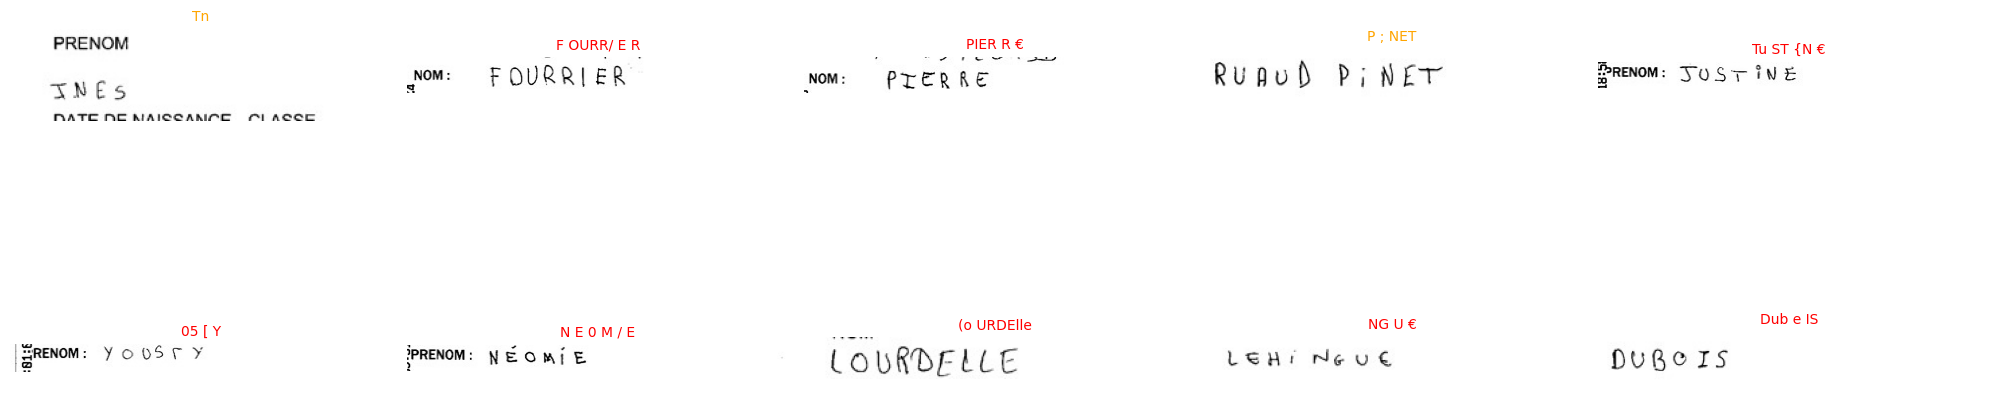

In [ ]:
!pip install easyocr
import easyocr
import matplotlib.pyplot as plt

# Initialize OCR reader
reader = easyocr.Reader(['en'])  # English

def confidence_color(prob):
    if prob >= 0.8:
        return 'green'
    elif prob >= 0.5:
        return 'orange'
    else:
        return 'red'

def show_predictions_colored(dataset, num_images=10):
    plt.figure(figsize=(20, 8))

    for i in range(num_images):
        img, _ = dataset[i]

        # Convert tensor to numpy
        img_np = img.permute(1,2,0).cpu().numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        if img_np.shape[2] == 1:
            img_np = img_np.squeeze(2)

        # OCR prediction
        results = reader.readtext((img_np * 255).astype('uint8'))

        # Display image
        plt.subplot(2, 5, i+1)
        plt.imshow(img_np, cmap='gray')
        plt.axis('off')

        # Overlay predicted text with color-coded confidence
        for (_, text, prob) in results:
            color = confidence_color(prob)
            plt.title(text, color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

# Show predictions for first 10 images
show_predictions_colored(dataset, num_images=10)
